In [2]:
from tensorflow.keras.datasets import mnist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
from collections import defaultdict, Counter
from PIL import Image
from sklearn.metrics import v_measure_score

from model.model import KohonenNetwork

# Przygotowanie danych

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_train_normalized = X_train_flat.astype('float32') / 255.0
SAMPLE_SIZE = 2000
mnist_features = X_train_normalized[:SAMPLE_SIZE]
mnist_labels = y_train_full[:SAMPLE_SIZE]

print(f"Shape of original data: {X_train_full.shape}")
print(f"Ready features: {mnist_features.shape}")
print(f"Ready labels: {mnist_labels.shape}")

Shape of original data: (60000, 28, 28)
Ready features: (2000, 784)
Ready labels: (2000,)


# Kod dla wizualizacji

In [30]:
def plot_som_mnist_weights(som, title="Visualization of Neuron Weights (Learned Digits)"):
    """
    Visualizes the weights of each neuron in the SOM as a grid of images.

    Parameters:
    - som: The trained KohonenNetwork instance.
    - title: The main title of the plot.
    """
    M, N, _ = som.weights.shape

    # Create a large grid of subplots (MxN)
    fig, axes = plt.subplots(M, N, figsize=(12, 12))

    for i in range(M):
        for j in range(N):
            # Extract the 784 weights of the current neuron and reshape to 28x28
            weight_image = som.weights[i, j].reshape(28, 28)

            # Plot the image in grayscale
            axes[i, j].imshow(weight_image, cmap='gray')
            axes[i, j].axis('off') # Hide axes for a cleaner look

    # Adjust spacing between images to make the grid compact
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.suptitle(title, fontsize=16)
    plt.show()

def plot_u_matrix(som, title="U-Matrix"):
    """
    Calculates and plots the U-Matrix of the SOM.
    Large values represent boundaries, small values represent clusters.
    """
    M, N, _ = som.weights.shape
    u_matrix = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            current_weight = som.weights[i, j]
            neighbor_distances = []

            # Check all 8 neighbors (including diagonals)
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0: continue
                    ni, nj = i + di, j + dj

                    if 0 <= ni < M and 0 <= nj < N:
                        neighbor_weight = som.weights[ni, nj]
                        dist = np.linalg.norm(current_weight - neighbor_weight)
                        neighbor_distances.append(dist)

            u_matrix[i, j] = np.mean(neighbor_distances)

    plt.figure(figsize=(7, 6))
    plt.pcolor(u_matrix, cmap='viridis') # 'viridis' is great for depth
    plt.colorbar(label='Average distance to neighbors')
    plt.title(title)
    plt.show()

def evaluate_som_clusters(predictions, true_labels):
    bmu_clusters = defaultdict(list)
    for bmu, label in zip(predictions, true_labels):
        # Convert NumPy types to standard Python ints for cleaner output
        bmu_key = (int(bmu[0]), int(bmu[1]))
        bmu_clusters[bmu_key].append(int(label))

    total_samples = len(true_labels)
    total_correct = 0
    cluster_info = {}

    # Sort keys (coordinates) to make the report easier to read
    sorted_bmus = sorted(bmu_clusters.keys())

    print(f"Total active neurons: {len(bmu_clusters)}\n")

    for bmu in sorted_bmus:
        labels_in_neuron = bmu_clusters[bmu]
        label_counts = Counter(labels_in_neuron)

        majority_class, majority_count = label_counts.most_common(1)[0]
        total_correct += majority_count

        neuron_purity = (majority_count / len(labels_in_neuron)) * 100
        cluster_info[bmu] = dict(label_counts)

        print(f"Neuron {bmu}: {len(labels_in_neuron)} samples, Purity: {neuron_purity:.2f}% | Counts: {dict(label_counts)}")

    overall_purity = total_correct / total_samples
    print("-" * 30)
    print(f"OVERALL NETWORK PURITY: {overall_purity * 100:.2f}%")

    return cluster_info, overall_purity

def plot_single_neuron(som, i, j):
    """
    Takes weights from (i, j) neuron and draws it as a 28x28 image.

    Parameters:
        - som: The trained KohonenNetwork instance.
        - i: Row index
        - j: Column index
    """
    # Wyciągnięcie wag dla zadanego neuronu
    neuron_weights = som.weights[i, j]

    # Przekształcenie płaskiego wektora (784) w obrazek (28, 28)
    weight_image = neuron_weights.reshape(28, 28)

    # Rysowanie
    plt.figure(figsize=(4, 4))
    plt.imshow(weight_image, cmap='gray')
    plt.title(f"Memory of neuron on position ({i}, {j})")
    plt.axis('off')
    plt.show()

In [26]:
def plot_hexagonal_umatrix(som, title="U-Matrix (Topologia Sześciokątna)"):
    """
    Oblicza i rysuje U-Matrix jako siatkę prawdziwych sześciokątów,
    kompatybilną z Twoją autorską klasą KohonenNetwork.
    """
    # Zabezpieczenie: upewniamy się, że rysujemy to dla odpowiedniej topologii
    if som.topology != 'hexagonal':
        print("Uwaga: Ta funkcja jest przeznaczona dla topologii 'hexagonal'.")
        print("Dla 'rectangular' użyj klasycznego plt.imshow().")
        return

    M, N, _ = som.weights.shape
    u_matrix = np.zeros((M, N))

    # KROK 1: Obliczanie prawdziwych odległości (6 sąsiadów)
    for i in range(M):
        for j in range(N):
            neighbors = []

            # Poziomi sąsiedzi
            if j > 0: neighbors.append(som.weights[i, j-1])
            if j < N - 1: neighbors.append(som.weights[i, j+1])

            # Pionowi i skośni sąsiedzi (plaster miodu)
            if i % 2 == 0:
                cols = [j-1, j] # Wiersz parzysty
            else:
                cols = [j, j+1] # Wiersz nieparzysty

            for c in cols:
                if 0 <= c < N:
                    if i > 0: neighbors.append(som.weights[i-1, c])
                    if i < M - 1: neighbors.append(som.weights[i+1, c])

            # Średnia odległość do sąsiadów
            distances = [np.linalg.norm(som.weights[i, j] - n) for n in neighbors]
            u_matrix[i, j] = np.mean(distances)

    # KROK 2: Rysowanie geometrii
    fig, ax = plt.subplots(figsize=(10, 8))

    # Skaler do mapowania wartości na kolory (od min do max z naszej u_matrix)
    norm = plt.Normalize(vmin=u_matrix.min(), vmax=u_matrix.max())
    cmap = plt.cm.viridis

    y_offset = np.sqrt(3) / 2

    for i in range(M):
        for j in range(N):
            # Współrzędne przestrzenne dla plastra miodu
            x = j + 0.5 * (i % 2)
            y = i * y_offset

            # Pobranie koloru; wysokie wartości = granice, niskie = centra klastrów
            color = cmap(norm(u_matrix[i, j]))

            # Tworzenie sześciokąta i dodanie go do wykresu
            hex_patch = RegularPolygon((x, y), numVertices=6, radius=0.58, orientation=0,
                                       facecolor=color, edgecolor='black', linewidth=0.3)
            ax.add_patch(hex_patch)

    # Konfiguracja wyświetlania
    ax.set_aspect('equal')
    ax.autoscale_view()
    ax.invert_yaxis() # Odwracamy oś Y, żeby wiersz 0 był na górze (jak w obrazkach)
    plt.axis('off')
    plt.title(title, fontsize=14)

    # Dodanie legendy kolorów (Colorbar)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    fig.colorbar(sm, ax=ax, label='Average distance to neighbors')

    plt.show()

def calculate_v_measure(predictions, true_labels):
    predicted_clusters_1d = [f'{bmu[0]}_{bmu[1]}' for bmu in predictions]
    return v_measure_score(true_labels, predicted_clusters_1d)

# Przykładowa sieć

In [4]:
som_mnist_hex = KohonenNetwork(
    grid_shape=(15, 15),
    input_dim=784,
    lambda_param=5e4,
    neighborhood_type='gaussian',
    topology='hexagonal',
    normalize_data=False
)

In [5]:
som_mnist_hex.train(data=mnist_features, num_epochs=50, sigma=1.0)

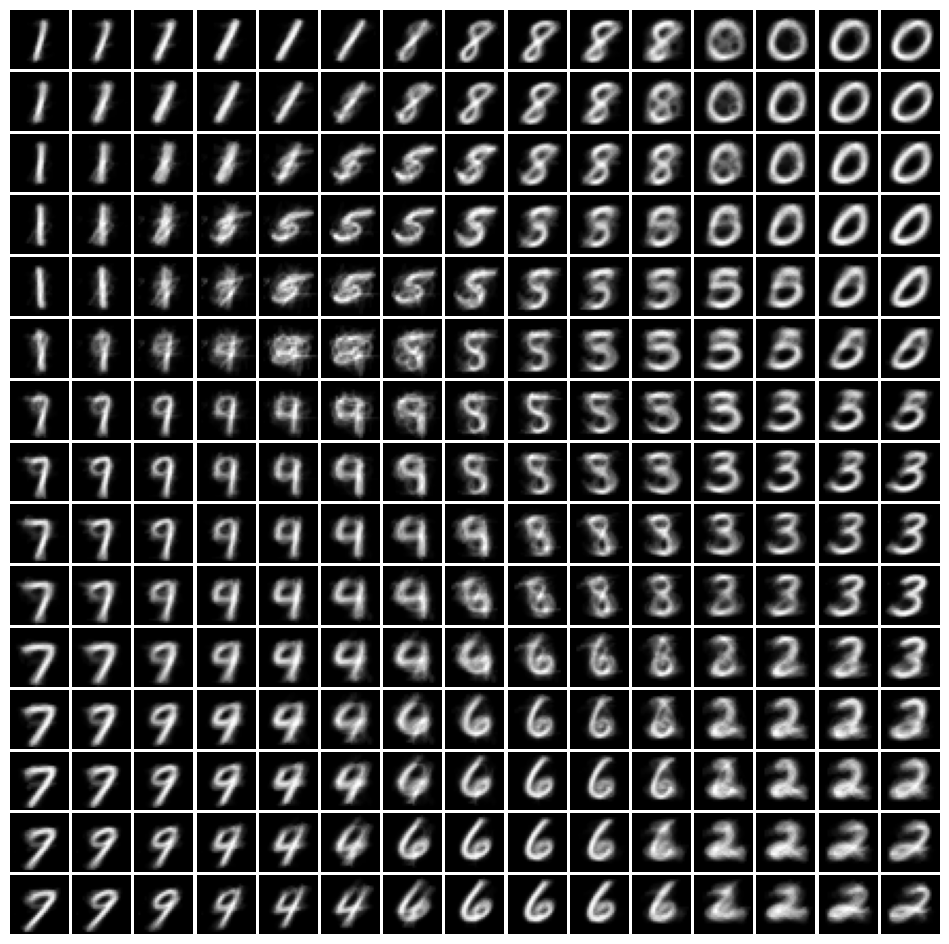

In [6]:
plot_som_mnist_weights(som_mnist_hex, title="")

In [8]:
mnist_predictions = som_mnist_hex.predict(data=mnist_features)
info_mnist, purity_mnist = evaluate_som_clusters(mnist_predictions, true_labels=mnist_labels)

Total active neurons: 224

Neuron (0, 0): 28 samples, Purity: 89.29% | Counts: {1: 25, 2: 3}
Neuron (0, 1): 18 samples, Purity: 72.22% | Counts: {1: 13, 2: 2, 7: 2, 4: 1}
Neuron (0, 2): 14 samples, Purity: 71.43% | Counts: {1: 10, 7: 4}
Neuron (0, 3): 17 samples, Purity: 100.00% | Counts: {1: 17}
Neuron (0, 4): 28 samples, Purity: 100.00% | Counts: {1: 28}
Neuron (0, 5): 29 samples, Purity: 96.55% | Counts: {1: 28, 7: 1}
Neuron (0, 6): 5 samples, Purity: 80.00% | Counts: {1: 4, 8: 1}
Neuron (0, 7): 17 samples, Purity: 100.00% | Counts: {8: 17}
Neuron (0, 8): 20 samples, Purity: 100.00% | Counts: {8: 20}
Neuron (0, 9): 16 samples, Purity: 100.00% | Counts: {8: 16}
Neuron (0, 10): 11 samples, Purity: 90.91% | Counts: {8: 10, 2: 1}
Neuron (0, 11): 1 samples, Purity: 100.00% | Counts: {3: 1}
Neuron (0, 12): 18 samples, Purity: 100.00% | Counts: {0: 18}
Neuron (0, 13): 14 samples, Purity: 100.00% | Counts: {0: 14}
Neuron (0, 14): 10 samples, Purity: 100.00% | Counts: {0: 10}
Neuron (1, 0): 

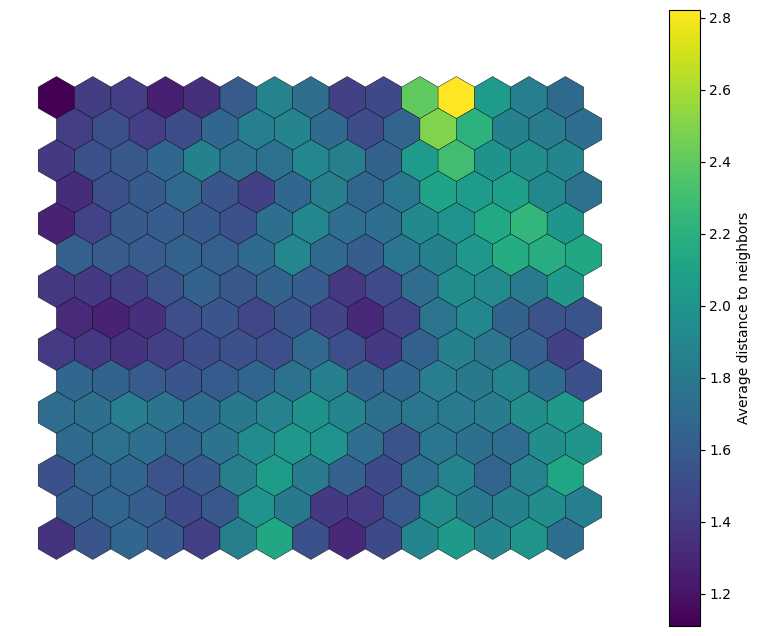

In [28]:
plot_hexagonal_umatrix(som_mnist_hex, title='')

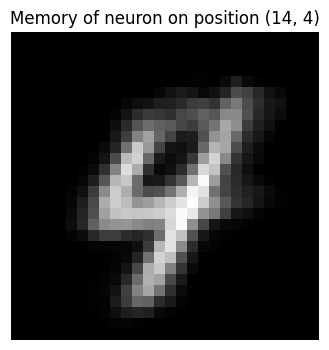

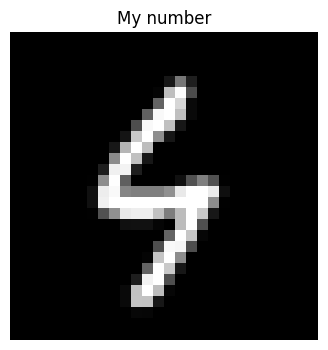

In [26]:
img = Image.open("C:/Users/Wojtek/Documents/MIO/SOM/my_numbers/4.png").convert('L').resize((28, 28))

img_array = np.array(img)
img_array = 255 - img_array

my_vector = img_array.astype('float32') / 255.0
my_vector_flat = my_vector.flatten()

my_bmu = som_mnist_hex.predict([my_vector_flat])[0]

plot_single_neuron(som_mnist_hex, my_bmu[0], my_bmu[1])
plt.figure(figsize=(4, 4))
plt.imshow(img_array, cmap='gray')
plt.title("My number")
plt.axis('off')
plt.show()

In [30]:
print(calculate_v_measure(mnist_predictions, mnist_labels))

0.5033675178405005


# Porównanie dla innych konfiguracji

## Rectangular - Gaussian

In [31]:
som_mnist_rec = KohonenNetwork(
    grid_shape=(15, 15),
    input_dim=784,
    lambda_param=5e4,
    neighborhood_type='gaussian',
    topology='rectangular',
    normalize_data=False
)

In [32]:
som_mnist_rec.train(data=mnist_features, num_epochs=50, sigma=1.0)

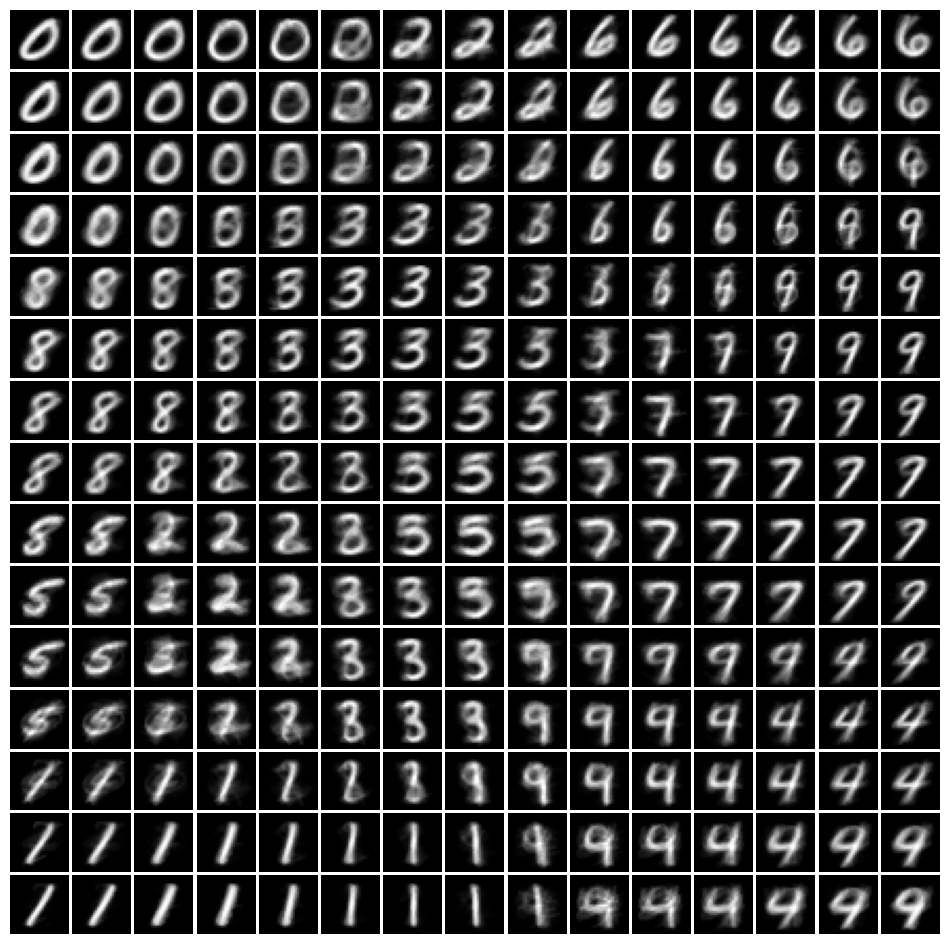

In [33]:
plot_som_mnist_weights(som_mnist_rec, title="")

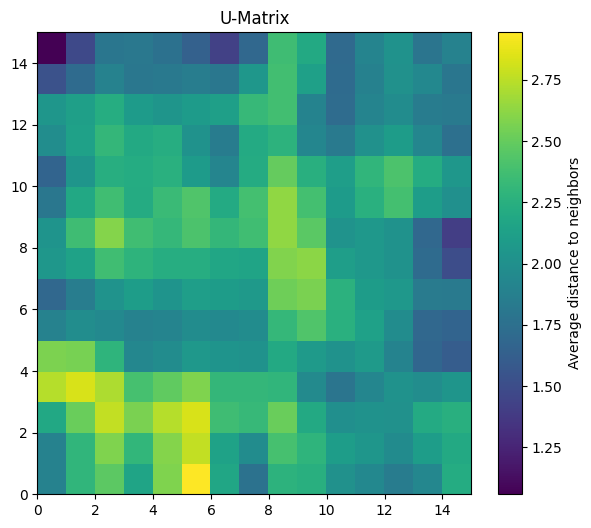

In [34]:
plot_u_matrix(som_mnist_rec)

In [35]:
mnist_predictions = som_mnist_rec.predict(data=mnist_features)
info_mnist, purity_mnist = evaluate_som_clusters(mnist_predictions, true_labels=mnist_labels)

Total active neurons: 223

Neuron (0, 0): 23 samples, Purity: 100.00% | Counts: {0: 23}
Neuron (0, 1): 12 samples, Purity: 100.00% | Counts: {0: 12}
Neuron (0, 2): 17 samples, Purity: 100.00% | Counts: {0: 17}
Neuron (0, 3): 14 samples, Purity: 100.00% | Counts: {0: 14}
Neuron (0, 4): 13 samples, Purity: 100.00% | Counts: {0: 13}
Neuron (0, 5): 1 samples, Purity: 100.00% | Counts: {2: 1}
Neuron (0, 6): 18 samples, Purity: 100.00% | Counts: {2: 18}
Neuron (0, 7): 21 samples, Purity: 100.00% | Counts: {2: 21}
Neuron (0, 8): 7 samples, Purity: 71.43% | Counts: {2: 5, 5: 1, 4: 1}
Neuron (0, 9): 12 samples, Purity: 100.00% | Counts: {6: 12}
Neuron (0, 10): 18 samples, Purity: 100.00% | Counts: {6: 18}
Neuron (0, 11): 17 samples, Purity: 100.00% | Counts: {6: 17}
Neuron (0, 12): 13 samples, Purity: 92.31% | Counts: {6: 12, 4: 1}
Neuron (0, 13): 5 samples, Purity: 100.00% | Counts: {6: 5}
Neuron (0, 14): 21 samples, Purity: 100.00% | Counts: {6: 21}
Neuron (1, 0): 5 samples, Purity: 100.00% |

In [36]:
print(calculate_v_measure(mnist_predictions, mnist_labels))

0.5106369706092467


## Mexican_hat-hexagonal

In [5]:
som_mnist_mex_hex = KohonenNetwork(
    grid_shape=(15, 15),
    input_dim=784,
    lambda_param=5e4,
    neighborhood_type='mexican_hat',
    topology='hexagonal',
    normalize_data=False
)

In [6]:
som_mnist_mex_hex.train(data=mnist_features, num_epochs=50, sigma=10.0)

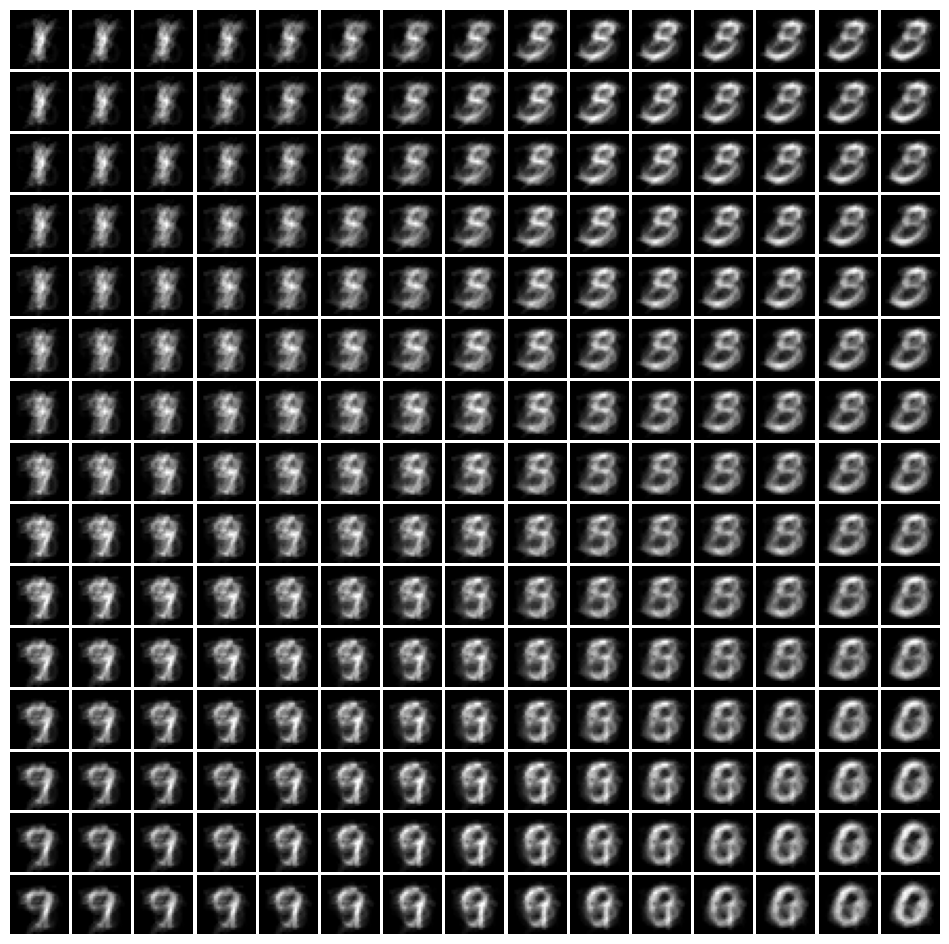

In [7]:
plot_som_mnist_weights(som_mnist_mex_hex, title="")

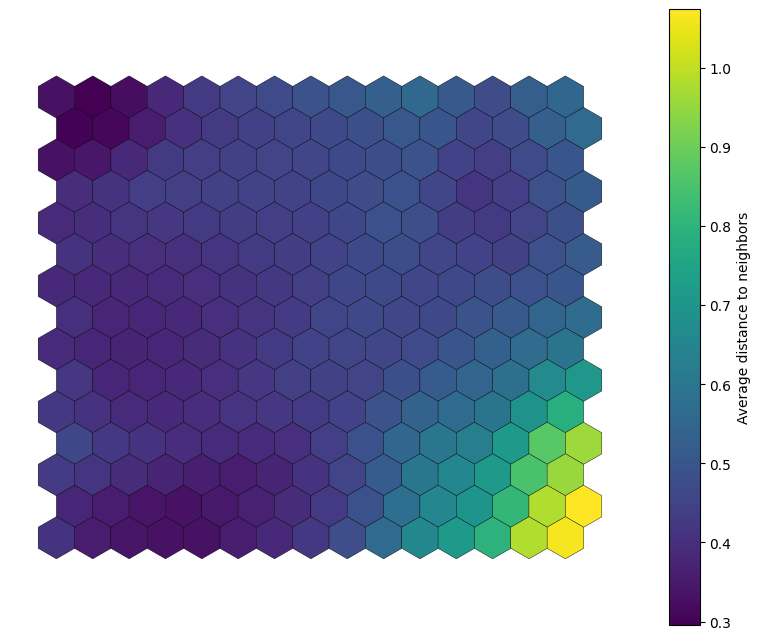

In [8]:
plot_hexagonal_umatrix(som_mnist_mex_hex, title='')

In [9]:
mnist_predictions = som_mnist_mex_hex.predict(data=mnist_features)
info_mnist, purity_mnist = evaluate_som_clusters(mnist_predictions, true_labels=mnist_labels)

Total active neurons: 211

Neuron (0, 0): 211 samples, Purity: 86.26% | Counts: {1: 182, 2: 20, 7: 6, 5: 1, 9: 1, 4: 1}
Neuron (0, 1): 5 samples, Purity: 40.00% | Counts: {5: 2, 4: 1, 2: 1, 1: 1}
Neuron (0, 2): 16 samples, Purity: 31.25% | Counts: {7: 1, 4: 2, 2: 4, 1: 1, 5: 3, 6: 5}
Neuron (0, 3): 26 samples, Purity: 34.62% | Counts: {4: 4, 5: 7, 2: 1, 1: 2, 6: 9, 7: 3}
Neuron (0, 4): 49 samples, Purity: 22.45% | Counts: {9: 8, 5: 11, 4: 6, 1: 8, 7: 4, 6: 7, 8: 2, 2: 3}
Neuron (0, 5): 61 samples, Purity: 22.95% | Counts: {4: 4, 1: 5, 9: 12, 7: 10, 8: 5, 5: 14, 6: 4, 2: 5, 3: 1, 0: 1}
Neuron (0, 6): 44 samples, Purity: 25.00% | Counts: {6: 7, 4: 4, 8: 7, 5: 11, 2: 6, 9: 3, 7: 2, 1: 1, 3: 3}
Neuron (0, 7): 35 samples, Purity: 22.86% | Counts: {8: 6, 6: 8, 9: 6, 5: 3, 2: 7, 7: 4, 4: 1}
Neuron (0, 8): 42 samples, Purity: 52.38% | Counts: {8: 22, 5: 6, 2: 9, 3: 2, 6: 3}
Neuron (0, 9): 33 samples, Purity: 27.27% | Counts: {3: 9, 8: 8, 5: 4, 0: 2, 2: 7, 9: 2, 7: 1}
Neuron (0, 10): 23 samples

## Mexican_hat-rectangular

In [10]:
som_mnist_mex_rec = KohonenNetwork(
    grid_shape=(15, 15),
    input_dim=784,
    lambda_param=5e4,
    neighborhood_type='mexican_hat',
    topology='rectangular',
    normalize_data=False
)

In [11]:
som_mnist_mex_rec.train(data=mnist_features, num_epochs=50, sigma=9.0)

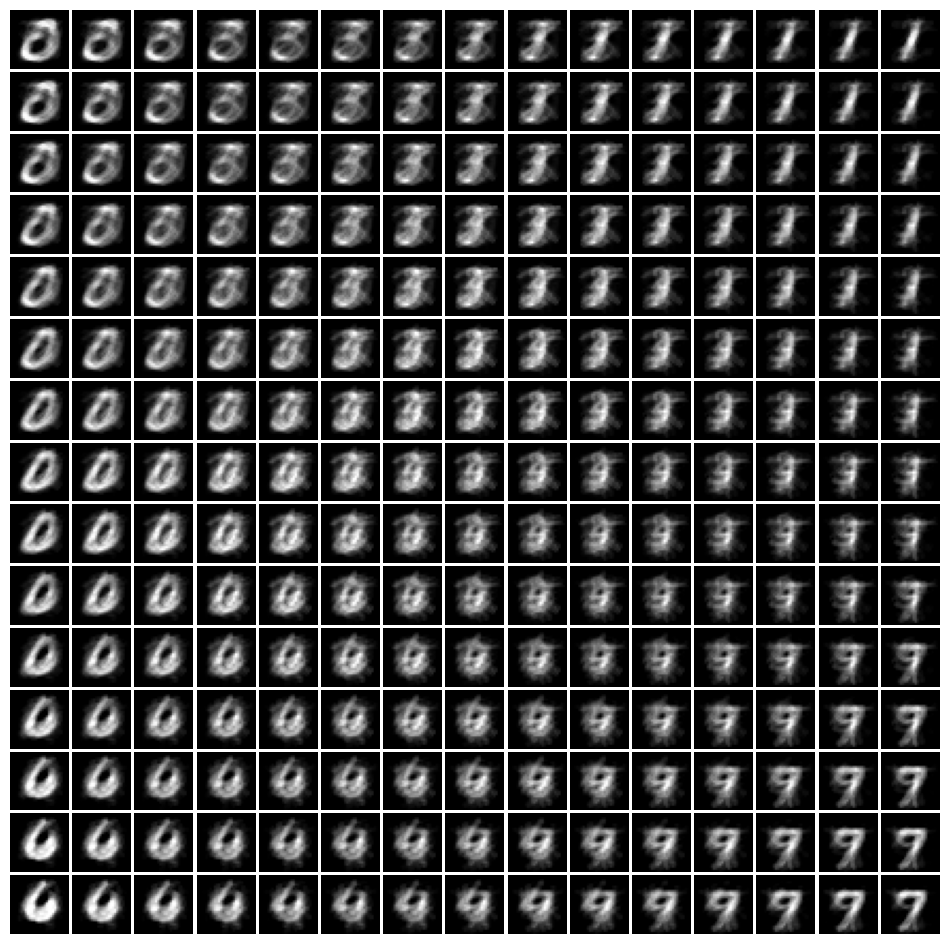

In [12]:
plot_som_mnist_weights(som_mnist_mex_rec, title="")

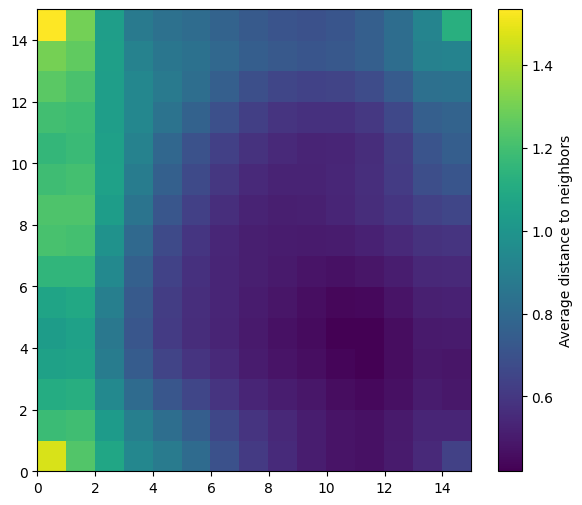

In [13]:
plot_u_matrix(som_mnist_mex_rec, title="")

In [14]:
mnist_predictions = som_mnist_mex_rec.predict(data=mnist_features)
info_mnist, purity_mnist = evaluate_som_clusters(mnist_predictions, true_labels=mnist_labels)

Total active neurons: 217

Neuron (0, 0): 42 samples, Purity: 97.62% | Counts: {0: 41, 5: 1}
Neuron (0, 1): 16 samples, Purity: 75.00% | Counts: {0: 12, 5: 3, 9: 1}
Neuron (0, 2): 19 samples, Purity: 42.11% | Counts: {3: 5, 0: 8, 5: 6}
Neuron (0, 3): 24 samples, Purity: 62.50% | Counts: {3: 15, 2: 2, 5: 4, 9: 1, 0: 2}
Neuron (0, 4): 47 samples, Purity: 61.70% | Counts: {3: 29, 5: 9, 8: 7, 0: 1, 9: 1}
Neuron (0, 5): 33 samples, Purity: 51.52% | Counts: {0: 3, 3: 17, 2: 4, 8: 5, 5: 4}
Neuron (0, 6): 22 samples, Purity: 59.09% | Counts: {3: 13, 8: 7, 2: 1, 5: 1}
Neuron (0, 7): 20 samples, Purity: 50.00% | Counts: {8: 10, 3: 5, 2: 5}
Neuron (0, 8): 17 samples, Purity: 82.35% | Counts: {8: 14, 2: 2, 3: 1}
Neuron (0, 9): 18 samples, Purity: 55.56% | Counts: {8: 10, 2: 7, 3: 1}
Neuron (0, 10): 8 samples, Purity: 62.50% | Counts: {2: 2, 1: 5, 8: 1}
Neuron (0, 11): 5 samples, Purity: 40.00% | Counts: {8: 1, 7: 1, 2: 2, 1: 1}
Neuron (0, 12): 11 samples, Purity: 54.55% | Counts: {2: 4, 1: 6, 9: 1

# Zbiór "Human Activity Recognition Using Smartphones"

In [20]:
data_s_train = pd.read_csv(
    r'C:/Users/Wojtek/Documents/MIO/SOM/datasets/train/X_train.txt',
    sep=r"\s+",
    header=None
).to_numpy()

data_s_test = pd.read_csv(
    r'C:/Users/Wojtek/Documents/MIO/SOM/datasets/test/X_test.txt',
    sep=r"\s+",
    header=None
).to_numpy()

data_s_test_y = pd.read_csv(
    r'C:/Users/Wojtek/Documents/MIO/SOM/datasets/test/y_test.txt',
    sep=r"\s+",
    header=None
).to_numpy()

In [21]:
data_s_train.shape

(7352, 561)

In [22]:
som_human_hex = KohonenNetwork(
    grid_shape=(20,20),
    input_dim=561,
    lambda_param=183800,
    topology='hexagonal',
    neighborhood_type='gaussian',
    normalize_data=True
)

In [23]:
som_human_hex.train(data=data_s_train, num_epochs=50, sigma=1.0)

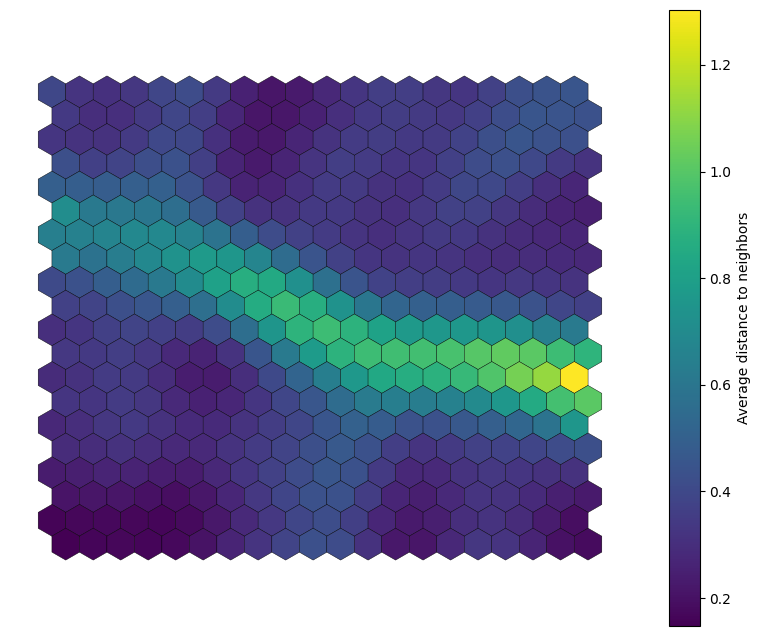

In [24]:
plot_hexagonal_umatrix(som_human_hex, title='')

In [28]:
y_preds = som_human_hex.predict(data_s_test)

calculate_v_measure(y_preds, data_s_test_y.flatten())

0.4200485369557858

In [32]:
info_human, purity_human = evaluate_som_clusters(y_preds, true_labels=data_s_test_y.flatten())

Total active neurons: 350

Neuron (0, 0): 1 samples, Purity: 100.00% | Counts: {2: 1}
Neuron (0, 2): 3 samples, Purity: 100.00% | Counts: {2: 3}
Neuron (0, 3): 21 samples, Purity: 100.00% | Counts: {2: 21}
Neuron (0, 4): 7 samples, Purity: 100.00% | Counts: {2: 7}
Neuron (0, 5): 3 samples, Purity: 66.67% | Counts: {2: 2, 1: 1}
Neuron (0, 6): 8 samples, Purity: 75.00% | Counts: {1: 6, 2: 1, 3: 1}
Neuron (0, 7): 12 samples, Purity: 100.00% | Counts: {1: 12}
Neuron (0, 8): 13 samples, Purity: 92.31% | Counts: {1: 12, 3: 1}
Neuron (0, 9): 21 samples, Purity: 95.24% | Counts: {3: 1, 1: 20}
Neuron (0, 10): 36 samples, Purity: 97.22% | Counts: {1: 35, 2: 1}
Neuron (0, 11): 45 samples, Purity: 100.00% | Counts: {1: 45}
Neuron (0, 12): 7 samples, Purity: 71.43% | Counts: {1: 5, 3: 2}
Neuron (0, 13): 20 samples, Purity: 70.00% | Counts: {1: 14, 3: 6}
Neuron (0, 14): 5 samples, Purity: 60.00% | Counts: {1: 3, 3: 2}
Neuron (0, 15): 5 samples, Purity: 100.00% | Counts: {3: 5}
Neuron (0, 16): 3 samp